# ⚙️ Your SR-SMILES Toolkit: Seamless Reaction Conversions

This notebook demonstrates how to use the `sr_smiles` library to transform **RXN (reaction) SMILES** into ** SR (Superimposed Reaction) SMILES**, and back again.

1️⃣ We will first explore how the **input data** affects the transformations:
- **A.** Fully mapped & balanced reactions (best case)
- **B.** Unbalanced reactions
- **C.** Unmapped reactions


2️⃣ Then we will look at the **different usage options**:
  - **Core functions** (simple, flexible)
      - `rxn_to_sr()`
      - `sr_to_rxn()`
  - **Wrapper classes** (convenient for bulk data)
      - `RxnToSr()`
      - `SrToRxn()`
  - **CLI** (file-based workflows)
      - `rxn2sr`
      - `sr2rxn`


The **core functions** are a great starting point to play around with the library and get familiar with SR SMILES. For practical use, we recommend using the **wrapper classes** or the **command line interface**.

3️⃣ Finally, we’ll walk through some examples and how to build a custom `RxnToSr` transformation class and discuss which parameters to configure based on your data.


---

## **1️⃣ Transforming Different Types of Reaction Data**

### **A. Fully Mapped & Balanced Reactions (The Ideal Case)**
#### ➡️ **Forward transformation: RXN ➜ SR**

When RXN SMILES are fully atom‑mapped and balanced, the transformation is straightforward. Let's take a look at an example:


In [28]:
from rdkit.Chem import Draw, rdChemReactions

from sr_smiles import SrToRxn, RxnToSr, sr_to_rxn, rxn_to_sr
from sr_smiles.chem_utils.smiles_utils import canonicalize

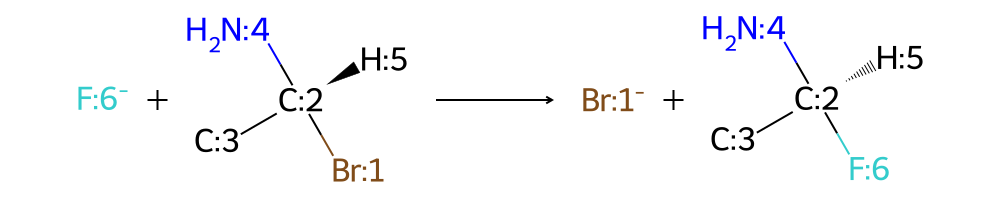

In [29]:
rxn_smiles = "[F-:6].[Br:1][C@:2]([H:5])([CH3:3])[NH2:4]>>[Br-:1].[CH3:3][C@:2]([H:5])([F:6])[NH2:4]"

# visualize the reaction
rxn = rdChemReactions.ReactionFromSmarts(rxn_smiles, useSmiles=True)
Draw.ReactionToImage(rxn)

**By default**, the generated **SR‑SMILES omits atom mapping**:


In [30]:
sr_smiles = rxn_to_sr(
    rxn_smiles,
    keep_atom_mapping=False,  # default
)

print(f"SR-SMILES (without mapping):\n\t{sr_smiles}\n")

SR-SMILES (without mapping):
	{[F-]|[F]}{~|-}{[C@]|[C@@]}({-|~}{[Br]|[Br-]})([H])([CH3])[NH2]



#### ⬅️ **Backward transformation: SR ➜ RXN**

For the backward transformation, atom mapping is required but will be assigned internally if it is not present in the SR. 
Whether this mapping is preserved in the resulting RXN depends on the user setting (`add_atom_mapping`).

**👉 Note:** While the exact atom mapping numbers in the generated RXN SMILES may differ from those in the original input, the chemical structure and the atom‑to‑atom correspondence remain identical: the mapping itself is equivalent even if the numeric labels change.



In [31]:
rxn_back_without_mapping = sr_to_rxn(
    sr_smiles, 
    add_atom_mapping=False  # default
)
rxn_back_with_mapping = sr_to_rxn(
    sr_smiles, 
    add_atom_mapping=True  # show atom mapping in the output smiles
)

print(f"RXN SMILES (original input):\n\t{rxn_smiles}\n")
print(f"RXN SMILES (without mapping numbers):\n\t{rxn_back_without_mapping}\n")
print(f"RXN SMILES (with added atom mapping numbers):\n\t{rxn_back_with_mapping}   <- atom mapping differs from the original, but the atom-to-atom correspondence matches!\n")


RXN SMILES (original input):
	[F-:6].[Br:1][C@:2]([H:5])([CH3:3])[NH2:4]>>[Br-:1].[CH3:3][C@:2]([H:5])([F:6])[NH2:4]

RXN SMILES (without mapping numbers):
	[F-].[C@](Br)([H])([CH3])[NH2]>>F[C@@]([H])([CH3])[NH2].[Br-]

RXN SMILES (with added atom mapping numbers):
	[F-:1].[C@:2]([Br:3])([H:4])([CH3:5])[NH2:6]>>[F:1][C@@:2]([H:4])([CH3:5])[NH2:6].[Br-:3]   <- atom mapping differs from the original, but the atom-to-atom correspondence matches!



If you choose to preserve atom mapping during the transformation (`keep_atom_mapping=True`), the round-trip conversion from `RXN → SR → RXN` will yield an **equivalent RXN SMILES string with its original atom mapping**. While the exact string might sometimes differ due to canonicalization, the chemical transformation represented remains identical.

In [32]:
sr_smiles = rxn_to_sr(
    rxn_smiles, 
    keep_atom_mapping=True  # preserve atom mapping in the SR
)

# convert SR back to RXN
rxn_back = sr_to_rxn(sr_smiles)

print(f"SR-SMILES (with mapping): \n\t{sr_smiles}\n")
print(f"Back to RXN SMILES: \n\t{rxn_back}  <- identical atom mapping!\n")

# atom mapping is identical
assert canonicalize(rxn_back) == canonicalize(rxn_smiles)

SR-SMILES (with mapping): 
	{[F-:6]|[F:6]}{~|-}{[C@:2]|[C@@:2]}({-|~}{[Br:1]|[Br-:1]})([H:5])([CH3:3])[NH2:4]

Back to RXN SMILES: 
	[F-:6].[C@:2]([Br:1])([H:5])([CH3:3])[NH2:4]>>[F:6][C@@:2]([H:5])([CH3:3])[NH2:4].[Br-:1]  <- identical atom mapping!



### **B. Unbalanced Reactions**

SR representations intrinsically describe a chemically balanced transformation. If your input RXN SMILES is unbalanced, the user must specify `balance_rxn=True` in the function call. 
After conversion, using `sr_to_rxn` to retrieve the RXN SMILES will return the balanced version of the reaction.

In [33]:
rxn_unbalanced = "[CH3:1][OH:2]>>[CH2:1]=[O:2].[OH2:3]"  # note: the oxygen atom with map number 3 is missing in the reactant

# forward transformation
sr_unbalanced = rxn_to_sr(
    rxn_unbalanced, 
    balance_rxn=True,  # set to `True` to allow for balancing
)
# transform back, now balanced
rxn_back_unbalanced = sr_to_rxn(sr_unbalanced)

print(f"SR (given unbalanced input): \n\t{sr_unbalanced}\n")
print(f"Back to RXN SMILES (now balanced): \n\t{rxn_back_unbalanced}\n")

SR (given unbalanced input): 
	{[CH3]|[CH2]}{-|=}{[OH]|[O]}.[OH2]

Back to RXN SMILES (now balanced): 
	[CH3][OH].[OH2]>>[CH2]=O.[OH2]



### **C. Unmapped Reactions**

To generate a SR‑SMILES, atom mapping is required. The core functions (`rxn_to_sr()` and `sr_to_rxn()`) expect mapped reactions and will raise an error if an unmapped one is provided. However, both the **wrapper classes** and the **command line interface** include an **integrated `RXNMapper` option** to automatically assign atom mapping, as we will see in section 2.

**👉 Note:** If a reaction is **unbalanced** and **partially mapped**, atoms that appear on only one side of the equation (reactant or product) will also receive atom‑map numbers.
Since these atoms have no corresponding partners, their mapping assignment is arbitrary.

In [34]:
rxn = "[CH3:1][OH:2]>>[CH2:1]=[O:2].[OH2]"  # note: the last OH2 in the product is not mapped, and does not occur in the reactant

# forward transformation
sr = rxn_to_sr(
    rxn, 
    keep_atom_mapping=True,
    balance_rxn=True,  # set to `True` to allow for balancing
)
# transform back, now balanced
rxn_back = sr_to_rxn(sr)

print(f"SR (unbalanced, partially unmapped input): \n\t{sr}")
print(f"Back to RXN SMILES (now balanced): \n\t{rxn_back}  <- the unmapped, unbalanced oxygen got assigned the map number 3 ")

SR (unbalanced, partially unmapped input): 
	{[CH3:1]|[CH2:1]}{-|=}{[OH:2]|[O:2]}.[OH2:3]
Back to RXN SMILES (now balanced): 
	[CH3:1][OH:2].[OH2:3]>>[CH2:1]=[O:2].[OH2:3]  <- the unmapped, unbalanced oxygen got assigned the map number 3 


---

## **2️⃣ Streamlining Your Workflow: Different Usage Options**

### 2.1 Core Functions (`rxn_to_sr`, `sr_to_rxn`)

As demonstrated in the previous sections, the core functions provide direct access to the `RXN → SR` and `SR → RXN` logic. They are best suited for:
- Quick experiments with single reactions.
- Integration into custom scripts.


### 2.2 Wrapper Classes (`RxnToSr`, `SrToRxn`)

These wrapper classes provide a convenient and efficient callable interface, particularly beneficial for:
- **Bulk data processing**: Lists, pandas Series, or DataFrames.
- **Streamlined mapping**: When dealing with multiple unmapped reactions, the wrapper efficiently handles the mapping process (e.g., calling RXNMapper once for a batch), significantly improving performance compared to individual function calls.
- **Unmapped data**: Allows for atom mapping via Schwaller et al.'s `RXNMapper`

#### ➡️ **Forward transformation: RXN ➜ SR**

### Class: `RxnToSr`

Let's take a look at it's attributes:

- `keep_atom_mapping` (`bool`, default `False`): Preserve atom‑mapping numbers in the output.  
- `remove_brackets` (`bool`, default `False`): Remove redundant square brackets from SMILES (e.g. `[C]` -> `C`).  
- `remove_hydrogens` (`bool`, default `False`): Remove explicit hydrogen atoms (e.g. `[CH3]` -> `[C]`).  
- `balance_rxn` (`bool`, default `False`): Balance the reaction before SR generation.  
- `rxn_col` (`Optional[str]`, default `None`): Column name in a DataFrame containing reaction SMILES. Not needed if data is a list or str.  
- `kekulize` (`bool`, default `False`): Convert aromatic atoms/bonds into explicit Kekulé notation.  
- `keep_aromatic_bonds` (`bool`, default `True`): When `kekulize=False`, decide whether aromatic bonds are explicitly marked with ":" (`True`) or not (`False`).  
- `mapping_method` (`Literal["rxn_mapper", "graph_overlay"] | None`, default `None`): Selects which atom‑mapping backend to use, if any (we suggest using `"rxn_mapper"`)

In [35]:
import pandas as pd

rxn_list = [
    "[N:1]#[C:2][C@@:3]1([H:6])[C:4]([H:7])([H:8])[O:5]1>>[N:1]#[C:2][C@@:3]([C:4][H:7])([O:5][H:8])[H:6]",
    "[O:1]([C@@:2]([C:3](=[O:4])[H:9])([C:5]#[C:6][H:10])[H:8])[H:7]>>[O:1]([C@@:2]([C:3][O:4][H:9])([C:5]#[C:6][H:10])[H:8])[H:7]",
]


# using the RxnToSr transform on a list of reactions
transform_to_sr = RxnToSr()
sr_results = transform_to_sr(rxn_list)

# using the RxnToSr transform on a pd.DataFrame
df_data = pd.DataFrame({"reactions": rxn_list})
transform_to_sr = RxnToSr(
    rxn_col="reactions"    # <- in this case we need to specify the column name!
)
df_data["sr_smiles"] = transform_to_sr(rxn_list)

assert sr_results == df_data["sr_smiles"].tolist()
print("SRs:\n\t" + "\n\t".join(sr_results))

SRs:
	[N]#[C][C@@]1([H])[C]2([H]){-|~}[H]{~|-}[O]1{-|~}2
	[O]([C@@]([C]1{=|-}[O]{~|-}[H]{-|~}1)([C]#[C][H])[H])[H]


#### ⬅️ **Backward transformation: `SrToRxn`**

### Class: `SrToRxn`

Let's take a look at it's attributes:

- `sr_col` (`Optional[str]`): Column name in a DataFrame containing SR-SMILES.
- `add_atom_mapping` (`bool`, optional): If True, ensures atom mappings are
            present in the output RXN SMILES. If False, atom mappings are stripped
            unless they were already present in the input. Default is False.
            

In [36]:
transform_to_rxn = SrToRxn(add_atom_mapping=True)
rxns = transform_to_rxn(sr_results)

print("RXNs:\n\t" + "\n\t".join(rxns))

RXNs:
	[N:1]#[C:2][C@@:3]1([H:4])[C:5]([H:6])([H:7])[O:8]1>>[N:1]#[C:2][C@@:3]([H:4])([C:5][H:6])[O:8][H:7]
	[O:1]([C@@:2]([C:3](=[O:4])[H:5])([C:6]#[C:7][H:8])[H:9])[H:10]>>[O:1]([C@@:2]([C:3][O:4][H:5])([C:6]#[C:7][H:8])[H:9])[H:10]


So, that’s pretty straightforward, right?

But more interestingly: what happens when our reactions are unbalanced, unmapped, or both?

In these cases, we can make use of the integrated RXNMapper:

In [37]:
# Example list of reactions
rxn_list = [
    "CCO>>CC=O",                # unmapped
    "N>>NC",                    # unmapped and unbalanced
    "[NH3:1]>>[NH2:1][CH3:2]",  # unbalanced
]

# using the wrapper with a pandas DataFrame
df_data = pd.DataFrame({"reaction": rxn_list})
transform_to_sr_df = RxnToSr(
    rxn_col="reaction",
    mapping_method="rxn_mapper",
    balance_rxn=True,
)
df_data["sr_smiles"] = transform_to_sr_df(df_data)
print("\nDataFrame with SRs:\n", df_data)


DataFrame with SRs:
                   reaction                         sr_smiles
0                CCO>>CC=O  [CH3]{[CH2]|[CH]}{-|=}{[OH]|[O]}
1                    N>>NC           {[NH3]|[NH2]}{~|-}[CH3]
2  [NH3:1]>>[NH2:1][CH3:2]           {[NH3]|[NH2]}{~|-}[CH3]


### **2.3 Command Line Interface (`rxn2sr`, `sr2rxn`)**

For file-based workflows or for users who prefer not to write Python code, the command line interface (CLI) is ideal. It reads a CSV file and writes the results to an output file. If no output file is specified, the results are written back to the input file with an additional column.
All other arguments are optional.

**The forward transformation:**
```bash
rxn2sr path/to/input.csv \              # required (input CSV)
    -o path/to/output.csv \             # optional output CSV
    --rxn-col rxn_smiles \              # name of the RXN SMILES column
    --sr-col sr_smiles \                # name of the new SR‑SMILES column
    --mapping-method rxn_mapper \       # mapping method (default: None)
    --keep-atom-mapping \               # preserve atom mapping
    --balance-rxn                       # enable reaction balancing

```

Output:
```bash
╭────────── 🚀 SR‑SMILES Converter v0.0.1 ─────-────╮
│                                                   │
│   👋 Welcome to SR‑SMILES                         │
│   Transforming Reaction SMILES ➡️ SR‑SMILES       │
│                                                   │
│   Input column:   'rxn_smiles'                    │
│   Output column:  'sr_smiles'                     │
│   Input file:     path/to/input.csv               │
│   Output file:    path/to/output.csv              │
│                                                   │
╰───────────────────────────────────────────────────╯
[2025-10-13 14:44] INFO: 📂 Loading CSV file from path/to/input.csv ... 
[2025-10-13 14:44] INFO: ✅ Loaded 100 rows.
[2025-10-13 14:44] INFO: 🔄 Transforming column 'rxn_smiles' → 'sr_smiles' ...
[2025-10-13 14:44] INFO: Reverse reactions for product-based transformation
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 448843.23it/s]
[2025-10-13 14:44] INFO: ✅ Transformation complete.
[2025-10-13 14:44] INFO: 💾 Writing results to: path/to/output.csv
[2025-10-13 14:44] INFO: 🎉 Done! Wrote 100 rows with new column 'sr_smiles'
  
```

**And the backward transformation:**

```bash
sr2rxn output_sr.csv \                  # required (input CSV)
    -o path/to/output.csv \             # optional output CSV
    --sr-col sr_smiles \                # name of the SR‑SMILES column
    --rxn-col rxn_back                  # name of the new RXN SMILES column
```


---

### 3️⃣ Examples and how to build a custom transform

Now to specify your custom transforation class insatance, let's go through the different options and set them according to your data: 
1. Is your data **unmapped**? If yes:`mapping_method="rxn_mapper"`
2. Does your data contain **unbalanced** reactions? If yes: `balance_rxn=True`
3. Is your data in **kekule** form? If yes: `kekulize=True`, Is not, do you want to keep eep explicit aromatic bonds in your data (`keep_aromatic_bonds`), e.g. "c:c:c" instead of "ccc"

And furthermore:
- Do you want to keep atom mapping int your SR? Probably not: `keep_atom_mapping=False`, but  If yes: `=True`
- Do you want to remove redundant brackets in the SR? If yes: `remove_brackets=True`
- Do you want to remove implicit hydrogens in the SR? If yes: `remove_hydrogens=True`

According to your answers you can then init your object: 


In [38]:
transform = RxnToSr(
    keep_atom_mapping=False,
    remove_brackets=False,
    remove_hydrogens=False,
    balance_rxn=True,
    rxn_col="rxn_smiles",
    kekulize=True,
    mapping_method="rxn_mapper",
)

### **Example 1: No explicit hydrogens and no redundant brackets**

As you may have noticed in a previous example, when we provide a reaction SMILES without explicit hydrogens or redundant brackets: `"CCO>>CC=O"`

... the SR transformation by default returns a SR SMILES that includes both brackets and hydrogens: `"[CH3]{[CH2]|[CH]}{-|=}{[OH]|[O]}"`

However, you might prefer to keep the output as minimal as the input. In that case, you can adjust the settings to omit explicit hydrogens and brackets.

In [39]:
# rxn without explict hydrogens and no redundant brackets
rxns = ["CCO>>CC=O"]

# default transformation
transform_to_sr = RxnToSr(
    mapping_method="rxn_mapper",
    keep_atom_mapping=False,
    balance_rxn=False,
)
sr_results = transform_to_sr(rxns)
print(f"SRs from list: \n\t{sr_results}")

# Transformation with hydrogen and bracket removal
transform_to_sr = RxnToSr(
    mapping_method="rxn_mapper",
    keep_atom_mapping=False,
    balance_rxn=False,
    remove_hydrogens=True,  # <- ADJUSTED
    remove_brackets=True,  # <- ADJUSTED
)
sr_results = transform_to_sr(rxns)
print(f"SRs from list: \n\t{sr_results}   <- note how the explicit hydrogens and redundant brackets are removed.")

SRs from list: 
	['[CH3]{[CH2]|[CH]}{-|=}{[OH]|[O]}']
SRs from list: 
	['CC{-|=}O']   <- note how the explicit hydrogens and redundant brackets are removed.


### **Example 2: Data in kekulé form**

In [40]:
rxns = ["[CH:1]1[CH:2]=[CH:3][CH:4]=[CH:5][C:6]=1[OH:7]>>[CH:1]1[CH:2]=[CH:3][CH:4]=[CH:5][CH:6]=1.[OH:7]"]

# With default aromatic form
transform_to_sr = RxnToSr(mapping_method="rxn_mapper")
sr_results = transform_to_sr(rxns)
print(f"SRs (aromatic, explicit aromatic bonds): \n\t{sr_results}")


# In aromatic form, but without explicit aromatic bonds (":")
transform_to_sr = RxnToSr(mapping_method="rxn_mapper", keep_aromatic_bonds=False)
sr_results = transform_to_sr(rxns)
print(f"SRs (aromatic, NO explicit aromatic bonds): \n\t{sr_results}")


# With Kekulization enabled
transform_to_sr = RxnToSr(
    mapping_method="rxn_mapper",
    kekulize=True,
)
sr_results = transform_to_sr(rxns)
print(f"SRs (kekule): \n\t{sr_results}")

SRs (aromatic, explicit aromatic bonds): 
	['[cH]1:{[c]|[cH]}({-|~}[OH]):[cH]:[cH]:[cH]:[cH]:1']
SRs (aromatic, NO explicit aromatic bonds): 
	['[cH]1{[c]|[cH]}({-|~}[OH])[cH][cH][cH][cH]1']
SRs (kekule): 
	['[CH]1={[C]|[CH]}({-|~}[OH])[CH]=[CH][CH]=[CH]1']


## 🎬 **And that’s a wrap!**

You’ve now seen how the **`sr_smiles` toolkit** enables seamless conversion between **RXN SMILES** and **SR‑SMILES**, whether working interactively, with bulk datasets, or from the command line.

You’re ready to integrate SR‑SMILES into your own chemistry + machine learning analyses!

 *Happy transforming and may all your reactions stay balanced!* 🦠🔬🔮🧪💥

